## package

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import camb
import cobaya
import os

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
plt.rc('font', size=14)

## Definition of fct

In [2]:
def expansion_rate(z, Omega_m, Omega_Lambda, w0=-1.0, wa=0): # by default lambdaCDM
    """    
    Parameters:
    z Redshift
    Omega_m Matter density parameter
    Omega_Lambda DE density parameter
    w0 constant equation of state parameter for DE
    wa varying equation of state parameter for DE

    Returns: E(z) = H(z)/H0
    """
    Omega_DE = Omega_Lambda * (1 + z)**(3 * (1 + w0 + wa)) * np.exp(-3 * wa * z / (1 + z))

    Omega_total = Omega_m * (1 + z)**3 + Omega_DE

    E_z = np.sqrt(Omega_total)
    return E_z

def trans_comoving_dist_array(z, par):
    """
    Returns: Transverse comoving distance D_M(z) in units of h^-1 Mpc
    """
    c = 299792.458  # km/s
    from scipy.integrate import quad

    Omega_m, w0, wa = par
    Omega_Lambda = 1 - Omega_m  # Assuming a flat universe

    def integrand(z_prime):
        return 1 / expansion_rate(z_prime, Omega_m, Omega_Lambda, w0, wa)

    # check if z is a scalar or an array
    if np.isscalar(z):
        integral, _ = quad(integrand, 0, z)
        return c/100 * integral
    
    integral1, _ = quad(integrand, 0, z[0])
    integrals = []
    for i in range(len(z)):
        part_int = quad(integrand, z[i-1], z[i])[0] if i > 0 else integral1
        integrals.append(part_int + (integrals[i-1] if i > 0 else 0))
    return [c/100 * el for el in integrals]

def Hubble_dist(z, par):# Omega_m, Omega_Lambda, w0=-1.0, wa=0):
    """
    Returns: Hubble distance D_H(z) in units of h^-1 Mpc
    """
    Omega_m, w0, wa = par
    Omega_Lambda = 1 - Omega_m  # Assuming a flat universe
    c = 299792.458  # km/s
    return c/100 / expansion_rate(z, Omega_m, Omega_Lambda, w0, wa)

def sound_horizon_approx(par):
    '''
    Need par = H0, Omega_m, Omega_b; returns h*r_d with an approximation formula Eq. 3.4 from 2212.04522
    '''
    a = -0.23
    b = -0.1
    c = -0.13
    Omega_m, H0 = par
    Omega_b = 0.02236/(H0/100)**2
    Neff = 3.04
    h = H0/100
    return h * 147.05 * ((Omega_m * h**2)/ 0.1432 )**a * ((Omega_b * h**2)/ 0.02236 )**b * (Neff/ 3.04)**c

def sound_horizon(par):
    '''
    Need par = H0, Omega_m, Omega_b; returns h*r_d
    '''
    H0, Om, Ob, w0, wa = par
    h = H0/100
    params = camb.CAMBparams()
    params.set_cosmology(H0=H0, ombh2=(Ob*h**2), omch2=((Om-Ob)*h**2), mnu=0.06, omk=0, tau=0.06)
    params.WantTransfer = False
    params.WantTensors = False
    params.WantDerivedParameters  = False
    params.Want_cl_2D_array = False
    params.Want_CMB_lensing = False
    params.DoLensing = False
    params.want_zdrag  = False
    params.want_zstar  = False

    params.set_dark_energy(w=w0, wa=wa, dark_energy_model='ppf')
    results = camb.get_results(params)

    return results.sound_horizon(1060) * h

def compute_DV(z, par):
    '''
    Returns D_V(z) in units of h^-1 Mpc, D_V = (z * D_M^2(z) * D_H(z))^(1/3)
    '''
    DM = trans_comoving_dist_array(z, par)
    DH = Hubble_dist(z, par)
    return (z * DM**2 * DH)**(1/3)

## Data generation

### generate DESI like data using $w_0 w_a \text{CDM}$ model

#### fake params & real data

In [5]:
# param
Omega_m = 0.3
w0 = -1.0
wa = 0.0
print(w0+wa)
H0 = 70.0
Omega_b = 0.02236/(H0/100)**2

param = [H0, Omega_m, Omega_b, w0, wa]

rd = sound_horizon(param)
rd_approx = sound_horizon_approx([Omega_m, H0])
print("Sound horizon from CAMB (h*rd in Mpc):" \
"", rd, "\nSound horizon from approximation (h*rd in Mpc):", rd_approx)

-1.0
Sound horizon from CAMB (h*rd in Mpc): 102.14972943141196 
Sound horizon from approximation (h*rd in Mpc): 102.31680637381366


In [ ]:
path_data = r"C:\EPFL\MA4\code\COBAYA_packages\data\bao_data\desi_bao_dr2"

dir_filename = os.listdir(path_data)
list_mean = []
for f in dir_filename:
    if f.endswith("mean.txt"):
        list_mean.append(f)
# print(list_mean)

data_filename = "desi_gaussian_bao_ALL_GCcomb_mean.txt"

data = np.loadtxt(path_data +"\\"+ data_filename, dtype=str)
# print(data)
print(len(data))

cov_file = data_filename.replace("mean", "cov")
cov_mat = np.loadtxt(path_data +"\\"+ cov_file) # mat with first term 0, 0 being sig**2 for DV/rd, then 2x2 blocks for the 6 pairs of DM/rd and DH/rd
                                        # beware of the last one that can actually be inversed (DH/rs first) following the order in data file

13


C:\Users\adrie\AppData\Local\Temp\ipykernel_3480\1511677249.py:12: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt(path_data +"\\"+ data_filename, dtype=str)


In [47]:
redshifts = data[:, 0]
redshifts = set(redshifts)
redshifts = list(redshifts)
redshifts = np.sort(redshifts)
# print(redshifts)

# data_typ = data[:, 2]
# data_typ = set(data_typ)
# data_typ = list(data_typ)
# print(data_typ)
data_typ = ['DH_over_rs', 'DM_over_rs', 'DV_over_rs']

#### compute fake data

In [70]:
param_ = [Omega_m, w0, wa]
z = [float(e) for e in redshifts[1:]]
z = np.array(z)
print(z)

DM_rd = [e/rd for e in trans_comoving_dist_array(z, param_)] # let's take same redshift as DESI data for now
DH_rd = [Hubble_dist(zi, param_)/rd for zi in z]
DV_rd = compute_DV(float(redshifts[0]), param_)/rd

fake_data = []
for i in range(len(z)):
    line = [z[i], DM_rd[i], data_typ[1]]
    fake_data.append(line)
    line = [z[i], DH_rd[i], data_typ[0]]
    fake_data.append(line)

line = [float(redshifts[0]), DV_rd, data_typ[2]]
fake_data.insert(0, line)

fake_data = np.array(fake_data)

fake_cov = cov_mat

[0.51  0.706 0.934 1.321 1.484 2.33 ]


In [51]:
print(fake_data)

[['0.295' '7.849536540432699' 'DV_over_rs']
 ['0.51' '13.165762876435387' 'DM_over_rs']
 ['0.51' '22.29454294836299' 'DH_over_rs']
 ['0.706' '17.29003722184605' 'DM_over_rs']
 ['0.706' '19.833754965657995' 'DH_over_rs']
 ['0.934' '21.518537703872177' 'DM_over_rs']
 ['0.934' '17.323308547880817' 'DH_over_rs']
 ['1.321' '27.530060545132876' 'DM_over_rs']
 ['1.321' '13.910887828680321' 'DH_over_rs']
 ['1.484' '29.700977570325048' 'DM_over_rs']
 ['1.484' '12.750418532295061' 'DH_over_rs']
 ['2.33' '38.53096497185554' 'DM_over_rs']
 ['2.33' '8.55167505002724' 'DH_over_rs']]


#### add randomness using covariance matrix

In [176]:
for i in range(len(fake_data)):
    if i == 0:
        print("DV/rd:", fake_data[i])
        rand = np.random.normal(float(fake_data[i][1]), np.sqrt(cov_mat[0, 0]))
        print("Randomly drawn value for DV/rd at z =", fake_data[i][0], ":\n", rand)
        fake_data[i][1] = rand
    elif i%2 == 0:
        cov = [[cov_mat[i-1, i-1], cov_mat[i-1, i]], [cov_mat[i, i-1], cov_mat[i, i]]]
        rand = np.random.multivariate_normal([float(fake_data[i-1][1]), float(fake_data[i][1])], cov)
        fake_data[i-1][1] = rand[0]
        fake_data[i][1] = rand[1]
        # print("Covariance matrix for DM/rd and DH/rd at z =", fake_data[i][0], ":\n", cov)
        # print("Randomly drawn values for DM/rd and DH/rd at z =", fake_data[i][0], ":\n", rand[0], rand[1])
        # if i==2: 
        #     print("Before DM/rd:", fake_data[i-1])
        #     print("Before DH/rd:", fake_data[i])
        #     nor = 20
        #     test_matrix = [[1/nor, -0.99/nor], [-0.99/nor, 1/nor]]
        #     rand = np.random.multivariate_normal([float(fake_data[i-1][1]), float(fake_data[i][1])], test_matrix, size=1000) 
        #     rand = np.array(rand)

DV/rd: ['0.295' '7.978978592910521' 'DV_over_rs']
Randomly drawn value for DV/rd at z = 0.295 :
 7.971572887277162


In [ ]:
# download the data in a txt file

pres = None # precision for w0 wa
n = 3
spec = f"_n{n}" # specifier 

filename = f''

if w0 < 0:
    filename += f'w0=neg{-round(w0, pres)}_'
else:
    filename += f'w0={round(w0, pres)}_'

if wa < 0:
    filename += f'wa=neg{-round(wa, pres)}_'
else:    
    filename += f'wa={round(wa, pres)}'

filename += spec
filename += '.txt'

folder = "./fake_BAO_data/"
filename = folder + filename

print("Saving fake data in file:", filename)
if os.path.exists(filename):
    print("File already exists")
else:
    np.savetxt(filename, fake_data, fmt="%s")

Saving fake data in file: ./fake_BAO_data/w0=neg1_wa=0_n2.txt


In [40]:
print(round(w0))

-1


#### Comparison plots

In [24]:
# DESI data
z_ = [0.510, 0.706, 0.934, 1.321, 1.484, 2.330]
dm = [13.588, 17.351, 21.576, 27.601, 30.512, 38.988] # DM/rd
dm_err = [0.167, 0.177, 0.152, 0.318, 0.760, 0.531]

dh = [21.863, 19.455, 17.641, 14.176, 12.817, 8.632] # DH/rd
dh_err = [0.425, 0.330, 0.193, 0.221, 0.516, 0.101]

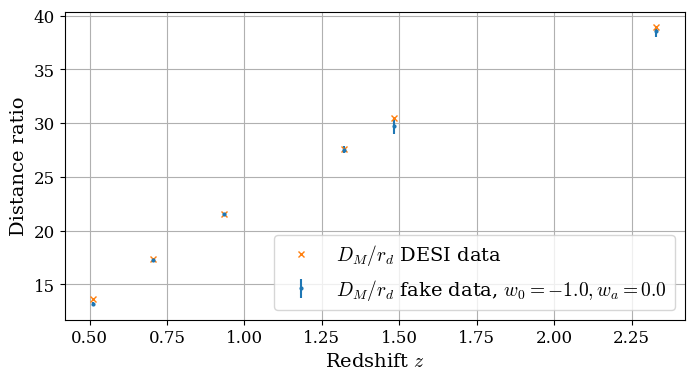

In [ ]:
# plot of comparison
plt.figure(figsize=(8,4))
plt.errorbar(z, DM_rd, yerr=dm_err, fmt='o', markersize=2, label=r'$D_M/r_d$ fake data, ' + f'$w_0={w0}, w_a={wa}$')
plt.plot(z_, dm, ls='None', marker='x', markersize=5, label=r'$D_M/r_d$ DESI data')
# plt.plot(z, DM_w0wa/0.7, ls='None', marker='+', markersize=5, label=r'$D_M/r_d$ $w_0w_a$CDM')
plt.xlabel(r'Redshift $z$')
plt.ylabel('Distance ratio')
plt.legend()
plt.grid()
plt.show()

C:\Users\adrie\AppData\Local\Temp\ipykernel_3480\2747575748.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


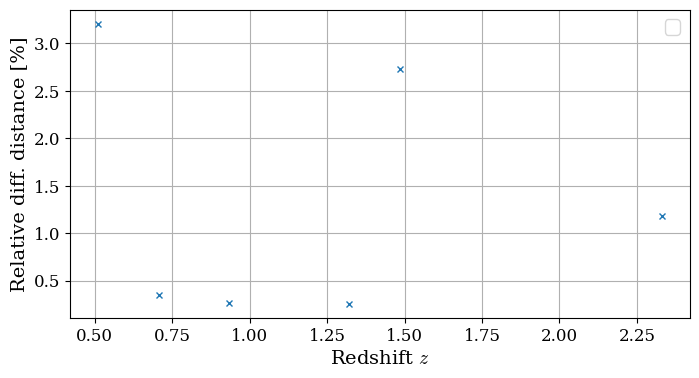

In [34]:
rel_diff = [abs((dm[i]-DM_rd[i])/DM_rd[i])*100 for i in range(len(dm))]
plt.figure(figsize=(8,4))
plt.plot(z_, rel_diff, ls='None', marker='x', markersize=5)
# plt.plot(z, DM_w0wa/0.7, ls='None', marker='+', markersize=5, label=r'$D_M/r_d$ $w_0w_a$CDM')
plt.xlabel(r'Redshift $z$')
plt.ylabel('Relative diff. distance [%]')
plt.legend()
plt.grid()
plt.show()

In [26]:
# # [z] [value at z] [quantity]
# line = ['#', '[z]', '[value at z]', '[quantity]']
# # insert in array the header line for the data file
# fake_data = [line] + fake_data
# print(fake_data)

### Contour plot using covariance matrix

In [28]:
cov_matrix_1 = [[cov_mat[1, 1], cov_mat[1, 2]], [cov_mat[2, 1], cov_mat[2, 2]]]
print("Covariance matrix:\n", cov_matrix_1)

Covariance matrix:
 [[np.float64(0.0283473742), np.float64(-0.0326062007)], [np.float64(-0.0326062007), np.float64(0.18392804)]]


In [29]:
# step 1
# for bivariate normal dist. the contour corresponds to constant chi-squared values
# 
trace = np.trace(cov_matrix_1)
det = np.linalg.det(cov_matrix_1)
lam1 = (trace + np.sqrt(trace**2 - 4*det))/2
lam2 = (trace - np.sqrt(trace**2 - 4*det))/2
print("Eigenvalues:", lam1, lam2)

Eigenvalues: 0.1904852039021073 0.021790210297892687


In [30]:
evals, evecs = np.linalg.eig(cov_matrix_1)
print("Eigenvalues:", evals)

print("Eigenvectors:\n", evecs)

Eigenvalues: [0.02179021 0.1904852 ]
Eigenvectors:
 [[-0.98037241  0.1971546 ]
 [-0.1971546  -0.98037241]]


Covariance matrix:
 [[np.float64(0.0283473742), np.float64(-0.0326062007)], [np.float64(-0.0326062007), np.float64(0.18392804)]]


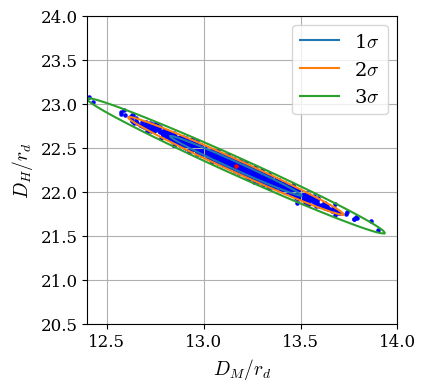

In [ ]:
for i in range(1):#len(dm)):
    center = (float(fake_data[i+1][1]), float(fake_data[i+2][1]))
    cov_matrix_1 = [[cov_mat[1, 1], cov_mat[1, 2]], [cov_mat[2, 1], cov_mat[2, 2]]]
    print("Covariance matrix:\n", cov_matrix_1)
    nor = 20
    test_matrix = [[1/nor, -0.99/nor], [-0.99/nor, 1/nor]]
    # cov_matrix_1 = test_matrix
    
    circle = np.array([np.cos(np.linspace(0, 2*np.pi, 100)), np.sin(np.linspace(0, 2*np.pi, 100))]) 
    plt.figure(figsize=(4,4))
    CL = [2.30, 6.17, 11.8]  # chi-squared values for 1, 2, 3 sigma contours
    plt.scatter(rand[:, 0], rand[:, 1], color='blue', s=5)#, label='Randomly drawn values')

    evals, evecs = np.linalg.eig(cov_matrix_1)
    # evecs = evecs.T
    lam1, lam2 = evals

    for c in CL:        
        # print(np.diag([np.sqrt(lam1*c), np.sqrt(lam2*c)]) @ np.array([circle[0], circle[1]]))
        ellipse = np.diag([np.sqrt(lam1*c), np.sqrt(lam2*c)]) @ np.array([circle[0], circle[1]])
        ellipse = evecs @ ellipse
        plt.plot(ellipse[0] + center[0], ellipse[1] + center[1], label=f'{int(np.sqrt(c))}' + r'$\sigma$')
    plt.scatter(center[0], center[1], color='red', s=5)
    plt.xlabel(r'$D_M/r_d$')
    plt.ylabel(r'$D_H/r_d$')
    plt.xlim(12.4, 14)
    plt.ylim(20.5, 24)
    plt.legend(loc = 'upper right')
    plt.grid()
    plt.show()

## Using cosmoprimo

In [ ]:
import cosmoprimo
import numpy as np

In [2]:
cosmo_planck = cosmoprimo.fiducial.Planck2018FullFlatLCDM()

In [ ]:
print(cosmo_planck['h'], cosmo_planck['Omega_cdm'], cosmo_planck['Omega_m'], cosmo_planck['Omega_b'], cosmo_planck['w0_fld'], cosmo_planck['wa_fld'])

0.6766 0.26066675992680977 0.31104850332553396 0.04897468161869667 -1.0 0.0


In [ ]:
bkg = cosmo_planck.get_background(engine="camb")

In [ ]:
path_data = r"C:\EPFL\MA4\code\COBAYA_packages\data\bao_data\desi_bao_dr2"
data_filename = "desi_gaussian_bao_ALL_GCcomb_mean.txt"

data = np.loadtxt(path_data +"\\"+ data_filename, dtype=str)
redshifts = data[:, 0]
redshifts = set(redshifts)
redshifts = list(redshifts)
redshifts = np.sort(redshifts)
redshifts = [float(e) for e in redshifts]

13


C:\Users\adrie\AppData\Local\Temp\ipykernel_46552\3574890761.py:4: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt(path_data +"\\"+ data_filename, dtype=str)


In [43]:
# DM = bkg.comoving_transverse_distance(redshifts)
# print(DM)
# rd = bkg.rs(1060)
# print("Sound horizon from CAMB (h*rd in Mpc):", rd)
# # DMover_rd = [DM[i]/rd for i in range(len(DM))]
# print(dir(bkg))

In [45]:
thermo = cosmo_planck.get_thermodynamics()

rdrag = thermo.rs_drag  # no parentheses needed, it's a property

DM = bkg.comoving_angular_distance(redshifts)
DH = 1 / bkg.efunc(redshifts) * 2997.92  # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
DV = (redshifts * DM**2 * DH)**(1/3)
DM_rd = DM / rdrag
DH_rd = DH / rdrag
DV_rd = DV / rdrag

print("rd =", rdrag)
print("DM/rd =", DM / rdrag)
print("DH/rd =", DH / rdrag)
print("DV/rd =", DV / rdrag)

rd = 99.61089178916403
DM/rd = [ 8.24448695 13.44855047 17.64026002 21.92883982 28.01256361 30.20641219
 39.11710411]
DH/rd = [25.7637077  22.68460244 20.13609977 17.55235284 14.06260723 12.88085648
  8.62206228]
DV/rd = [ 8.02390694 12.79039924 16.41584868 19.90235686 24.42819953 25.93337124
 31.32565468]


In [49]:
data_typ = ['DH_over_rs', 'DM_over_rs', 'DV_over_rs']

#### compute fake data

In [50]:
fake_data = []
for i in range(1, len(redshifts)):
    line = [redshifts[i], DM_rd[i], data_typ[1]]
    fake_data.append(line)
    line = [redshifts[i], DH_rd[i], data_typ[0]]
    fake_data.append(line)

line = [float(redshifts[0]), DV_rd[0], data_typ[2]]
fake_data.insert(0, line)

fake_data = np.array(fake_data)

print(fake_data)

[['0.295' '8.023906939535143' 'DV_over_rs']
 ['0.51' '13.448550466326262' 'DM_over_rs']
 ['0.51' '22.6846024426481' 'DH_over_rs']
 ['0.706' '17.640260024323926' 'DM_over_rs']
 ['0.706' '20.136099772480577' 'DH_over_rs']
 ['0.934' '21.928839823381864' 'DM_over_rs']
 ['0.934' '17.552352837543808' 'DH_over_rs']
 ['1.321' '28.0125636088651' 'DM_over_rs']
 ['1.321' '14.062607233407737' 'DH_over_rs']
 ['1.484' '30.206412187435724' 'DM_over_rs']
 ['1.484' '12.880856484247142' 'DH_over_rs']
 ['2.33' '39.11710411349919' 'DM_over_rs']
 ['2.33' '8.622062275851818' 'DH_over_rs']]


In [53]:
# dir_ = r'..\fake_BAO_data\LCDM\exact_flat_Planck'
filename = 'fake_data.txt'

folder = "../fake_BAO_data/LCDM/exact_flat_Planck"
filename = folder + '/' + filename

print("Saving fake data in file:", filename)
if os.path.exists(filename):
    print("File already exists")
else:
    np.savetxt(filename, fake_data, fmt="%s")

Saving fake data in file: ../fake_BAO_data/LCDM/exact_flat_Planck/fake_data.txt


### Individual z

In [ ]:
folder = "../fake_BAO_data/LCDM/exact_flat_Planck"
filename = folder + '/'
for i in range(len(redshifts)):
    fake_data = []
    if i == 0:
        line = [float(redshifts[0]), DV_rd[0], data_typ[2]]
        f = filename +f'z{i+1}.txt'
        fake_data.insert(0, line)
        if os.path.exists(f):
            print("File already exists:", f)
            continue
        np.savetxt(f, fake_data, fmt="%s")
        # print(f, fake_data)
    else:
        line = [redshifts[i], DM_rd[i], data_typ[1]]
        fake_data.append(line)
        line = [redshifts[i], DH_rd[i], data_typ[0]]
        fake_data.append(line)
        f = filename + f'z{i+1}.txt'
        if os.path.exists(f):
            print("File already exists:", f)
            continue
        np.savetxt(f, fake_data, fmt="%s")
        # print(f, fake_data)

# general fct

In [ ]:
def create_DESI_fid_data(redshifts, DESI_style=False):
    import cosmoprimo
    cosmo_planck = cosmoprimo.fiducial.DESI()
    bkg = cosmo_planck.get_background(engine="class")
    thermo = cosmo_planck.get_thermodynamics()
    rdrag = thermo.rs_drag  # no parentheses needed, it's a property

    DM = bkg.comoving_angular_distance(redshifts)
    DH = 1 / bkg.efunc(redshifts) * 2997.92  # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV = (redshifts * DM**2 * DH)**(1/3)
    DM_rd = DM / rdrag
    DH_rd = DH / rdrag
    DV_rd = DV / rdrag

    data_typ = ['DH_over_rs', 'DM_over_rs', 'DV_over_rs']

    fake_data = []
    if DESI_style:
        for i in range(1, len(redshifts)):
            line = [redshifts[i], DM_rd[i], data_typ[1]]
            fake_data.append(line)
            line = [redshifts[i], DH_rd[i], data_typ[0]]
            fake_data.append(line)

        line = [float(redshifts[0]), DV_rd[0], data_typ[2]]
        fake_data.insert(0, line)
    else:
        for i in range(len(redshifts)):
            line = [redshifts[i], DM_rd[i], data_typ[1]]
            fake_data.append(line)
            line = [redshifts[i], DH_rd[i], data_typ[0]]
            fake_data.append(line)

    return np.array(fake_data)

def save_mean_data(fake_data, folder, filename):
    if not os.path.exists(folder):
        os.makedirs(folder)
    f = folder + '/' + filename
    if os.path.exists(f):
        print("File already exists:", f)
    else:
        np.savetxt(f, fake_data, fmt="%s")


def create_cov_from_Fisher(Fish_inv, fake_data, folder, filename, DESI_style=False):
    n = len(fake_data)
    cov_mat = np.zeros((n, n))
    
    if DESI_style:
        print("A coder")
    else:
